# Advanced learning laboratory: continuous optimization of DAG structure

The NOTEARS construction turns acyclicity into a smooth equality constraint. For a weighted adjacency matrix $W\in\mathbb R^{d\times d}$,

$$
h(W)=\operatorname{tr}\left(e^{W\circ W}\right)-d
$$

is zero if and only if the directed graph represented by $W$ is acyclic. This permits structure learning with continuous optimization rather than a combinatorial DAG search.

In [1]:
CHAPTER_DIR="ch14"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from scipy.linalg import expm
from scipy.optimize import minimize
n=4; S=1200
Wtrue=np.array([[0,.8,0,0],[0,0,-.7,.55],[0,0,0,.9],[0,0,0,0.]])
X=np.zeros((S,n)); E=RNG.normal(scale=.7,size=(S,n))
for j in range(n): X[:,j]=E[:,j]+X@Wtrue[:,j]

def hfun(W): return np.trace(expm(W*W))-n
print('h(true DAG)=',hfun(Wtrue))
Wcycle=Wtrue.copy(); Wcycle[3,0]=.4; print('h(with cycle)=',hfun(Wcycle))
# Penalized augmented objective; diagonal fixed by parameterization
mask=~np.eye(n,dtype=bool)
def unpack(v):
    W=np.zeros((n,n)); W[mask]=v; return W
lam=.02; rho=30.
def obj(v):
    W=unpack(v); R=X-X@W; return .5*np.mean(R*R)+lam*np.sqrt(W*W+1e-8).sum()+.5*rho*hfun(W)**2
res=minimize(obj,np.zeros(mask.sum()),method='L-BFGS-B',options={'maxiter':1500,'ftol':1e-12})
What=unpack(res.x); What[np.abs(What)<.12]=0
print('success',res.success,'h(What)=',hfun(What)); print(np.round(What,2))

h(true DAG)= 0.0
h(with cycle)= 0.022267670740967915


success True h(What)= 0.01985055665070501
[[ 0.    0.42  0.    0.  ]
 [ 0.15  0.   -0.48  0.18]
 [ 0.   -0.19  0.    0.46]
 [ 0.    0.    0.19  0.  ]]


Saved ch14_02_notears_acyclicity


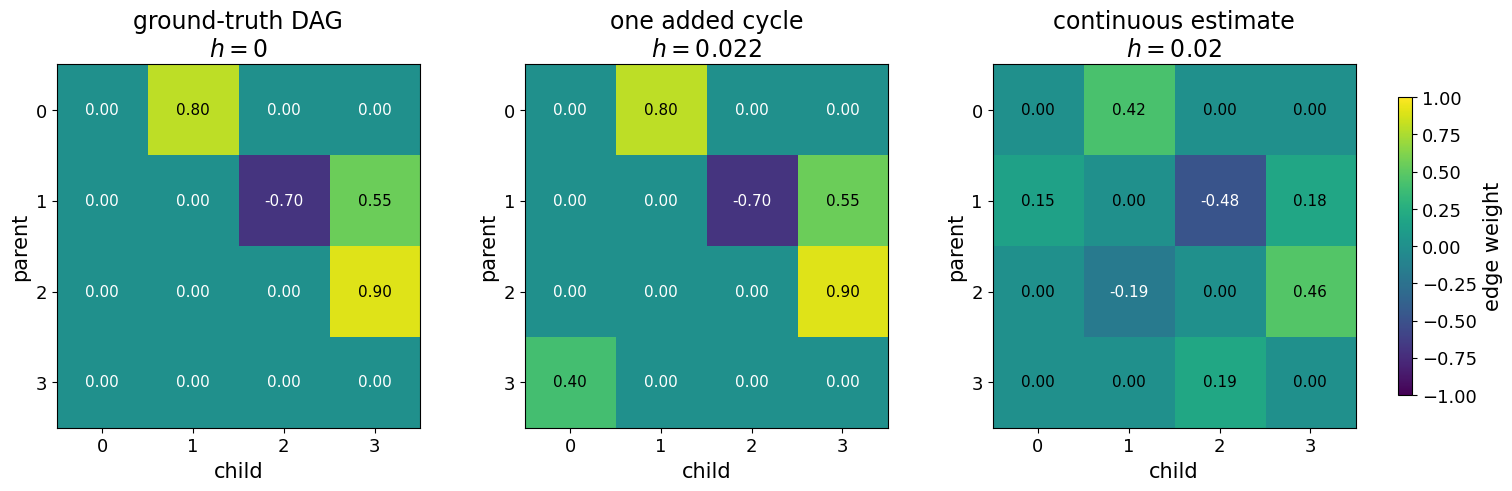

In [3]:
fig,axes=plt.subplots(1,3,figsize=(15.5,4.8), constrained_layout=True)
mats=[Wtrue,Wcycle,What]
titles=['ground-truth DAG','one added cycle','continuous estimate']
for ax,M,t in zip(axes,mats,titles):
    im=ax.imshow(M,vmin=-1,vmax=1)
    ax.set_title(t+f"\n$h={hfun(M):.2g}$")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    annotate_heatmap(ax,im,M)
    ax.set_xlabel('child'); ax.set_ylabel('parent')
cbar=fig.colorbar(im, ax=axes, shrink=.82, pad=.03)
cbar.set_label('edge weight')
save_figure(fig,'ch14_02_notears_acyclicity')
plt.show()

## Stress test: satisfying acyclicity does not guarantee recovering the correct DAG

The smooth constraint $h(W)=0$ solves one part of the problem: it rules out directed cycles. It does **not** by itself guarantee statistical identifiability or reliable finite-sample recovery.

We repeat the same penalized continuous optimization as the sample size changes. The resulting estimate can remain nearly acyclic while its edge support is wrong. This separates an optimization certificate from a statistical guarantee.

Saved ch14_02_notears_stress_test


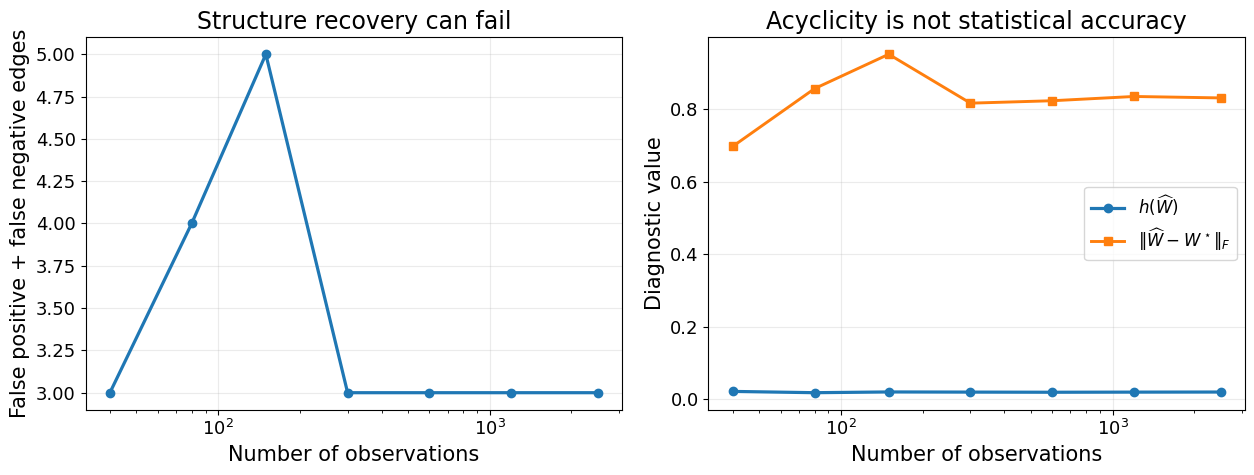

In [4]:
def simulate_sem(sample_count, seed_value, noise_scale=0.7):
    rng_local = np.random.default_rng(seed_value)
    X_local = np.zeros((sample_count, n))
    E_local = rng_local.normal(scale=noise_scale, size=(sample_count, n))
    for j in range(n):
        X_local[:, j] = E_local[:, j] + X_local @ Wtrue[:, j]
    return X_local

def fit_continuous_dag(X_local, lam_local=0.02, rho_local=30.0):
    def objective(v):
        W = unpack(v)
        residual = X_local - X_local @ W
        return (0.5 * np.mean(residual * residual)
                + lam_local * np.sqrt(W * W + 1e-8).sum()
                + 0.5 * rho_local * hfun(W)**2)
    result = minimize(objective, np.zeros(mask.sum()), method="L-BFGS-B",
                      options={"maxiter": 1200, "ftol": 1e-11})
    return unpack(result.x), result

def support_error(W_est, threshold=0.12):
    true_support = np.abs(Wtrue) > 0
    est_support = np.abs(W_est) >= threshold
    np.fill_diagonal(est_support, False)
    false_pos = np.logical_and(est_support, ~true_support).sum()
    false_neg = np.logical_and(~est_support, true_support).sum()
    return int(false_pos + false_neg)

sample_grid = np.array([40, 80, 150, 300, 600, 1200, 2500])
support_errors = []
acyclicity_values = []
weight_errors = []
for idx, sample_count in enumerate(sample_grid):
    X_test = simulate_sem(int(sample_count), 700 + idx)
    W_est, result = fit_continuous_dag(X_test)
    support_errors.append(support_error(W_est))
    acyclicity_values.append(hfun(W_est))
    weight_errors.append(np.linalg.norm(W_est - Wtrue))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))
axes[0].plot(sample_grid, support_errors, marker="o", linewidth=2.3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of observations")
axes[0].set_ylabel("False positive + false negative edges")
axes[0].set_title("Structure recovery can fail")
axes[0].grid(alpha=0.25)

axes[1].semilogx(sample_grid, np.maximum(acyclicity_values, 1e-12), marker="o",
                 linewidth=2.3, label=r"$h(\widehat W)$")
axes[1].semilogx(sample_grid, weight_errors, marker="s", linewidth=2.1,
                 label=r"$\|\widehat W-W^\star\|_F$")
axes[1].set_xlabel("Number of observations")
axes[1].set_ylabel("Diagnostic value")
axes[1].set_title("Acyclicity is not statistical accuracy")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch14_02_notears_stress_test")
plt.show()

## Exercises

1. Verify numerically that a strictly upper-triangular matrix has $h(W)=0$.
2. Add a single weak backward edge and study the small-edge asymptotics of $h(W)$.
3. Replace the quadratic penalty on $h(W)$ by an augmented-Lagrangian update and compare convergence.
4. Construct two Markov-equivalent DAGs. Can observational least-squares data alone distinguish their causal directions without additional assumptions?